# Premier League Club Performance & Discipline Index

## Data Analysis and Visualization CA1

This notebook develops a **composite indicator** for Premier League clubs using multiple seasons of match-level data.

The final index compares clubs using three dimensions:

1. **Attack Index**
2. **Defence Index**
3. **Discipline Index**

The aim is to create one final score that can compare teams across seasons.

## 1. Theoretical Framework

Football team performance is multidimensional. A team cannot be judged using only one statistic such as points, goals, or possession. A strong team should be able to attack effectively, defend well, and maintain discipline.

For this project, the composite index is structured around three sub-indices:

- **Attack Index**: measures attacking strength and chance creation.
- **Defence Index**: measures defensive stability and ability to prevent goals/chances.
- **Discipline Index**: measures how controlled a team is using fouls and cards.

The final composite indicator combines these sub-indices into one score.

## 2. Import Libraries

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
VISUALS_DIR = BASE_DIR / 'visuals'

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete")
print("Base directory:", BASE_DIR)
print("Raw data folder:", RAW_DIR)

Setup complete
Base directory: c:\Users\ehima\Downloads\dav_premier_league_notebook_project\dav_premier_league_notebook_project
Raw data folder: c:\Users\ehima\Downloads\dav_premier_league_notebook_project\dav_premier_league_notebook_project\data\raw


In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

print("scikit-learn loaded successfully")

scikit-learn loaded successfully


## 3. Data Selection

The project uses Premier League CSV data from Football-Data.co.uk. Each CSV represents one season. Using several seasons gives multiple datasets and allows the index to compare club performance across time.

The data includes indicators such as:

- Full-time home goals and away goals
- Shots and shots on target
- Corners
- Fouls
- Yellow cards
- Red cards

These indicators are suitable because they represent attacking, defensive and disciplinary performance.

In [4]:
# Direct CSV links from Football-Data.co.uk
# E0 = English Premier League
season_urls = {
    '2020_21': 'https://www.football-data.co.uk/mmz4281/2021/E0.csv',
    '2021_22': 'https://www.football-data.co.uk/mmz4281/2122/E0.csv',
    '2022_23': 'https://www.football-data.co.uk/mmz4281/2223/E0.csv',
    '2023_24': 'https://www.football-data.co.uk/mmz4281/2324/E0.csv',
    '2024_25': 'https://www.football-data.co.uk/mmz4281/2425/E0.csv',
}

raw_dfs = []

for season, url in season_urls.items():
    print(f'Downloading {season}...')
    df = pd.read_csv(url)
    df['Season'] = season
    file_path = RAW_DIR / f'E0_{season}.csv'
    df.to_csv(file_path, index=False)
    raw_dfs.append(df)

matches = pd.concat(raw_dfs, ignore_index=True)
print(matches.shape)
matches.head()

(1900, 133)


C:\Users\ehima\AppData\Local\Temp\ipykernel_17080\1205278897.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Season'] = season


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,VCH,VCD,VCA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,...,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season,BFH,BFD,BFA,1XBH,1XBD,1XBA,BFEH,BFED,BFEA,BFE>2.5,BFE<2.5,BFEAHH,BFEAHA,BFCH,BFCD,BFCA,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA
0,E0,12/09/2020,12:30,Fulham,Arsenal,0,3,A,0,1,A,C Kavanagh,5,13,2,6,12,12,2,3,2,2,0,0,6.00,4.33,1.53,5.50,4.25,1.57,6.00,3.90,1.57,6.16,4.51,1.56,6.50,4.2,1.53,6.50,4.20,1.55,6.55,4.55,1.60,5.94,4.34,1.55,1.72,2.10,...,5.75,4.20,1.71,5.36,3.93,1.67,2.0,1.80,2.06,1.86,2.10,1.92,2.00,1.84,0.75,2.01,1.89,2.02,1.91,2.13,1.92,2.02,1.87,2020_21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,12/09/2020,15:00,Crystal Palace,Southampton,1,0,H,1,0,H,J Moss,5,9,3,5,14,11,7,3,2,1,0,0,3.10,3.25,2.37,3.00,3.20,2.45,3.15,2.95,2.40,3.32,3.29,2.40,3.20,3.2,2.35,3.20,3.20,2.40,3.36,3.36,2.50,3.18,3.22,2.39,2.20,1.66,...,3.25,3.33,2.55,3.08,3.22,2.47,2.2,1.66,2.26,1.72,2.27,1.78,2.18,1.70,0.25,1.78,2.13,1.79,2.17,1.85,2.18,1.79,2.12,2020_21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,12/09/2020,17:30,Liverpool,Leeds,4,3,H,3,2,H,M Oliver,22,6,6,3,9,6,9,0,1,0,0,0,1.28,6.00,9.50,1.26,6.25,10.50,1.35,5.00,8.50,1.31,6.25,9.92,1.27,6.0,10.00,1.30,5.75,10.50,1.35,6.50,10.75,1.30,5.96,9.68,1.53,2.50,...,1.30,6.75,12.27,1.28,6.16,10.63,1.5,2.62,1.51,2.76,1.53,2.82,1.50,2.62,-1.50,1.85,2.05,1.85,2.08,1.90,2.16,1.84,2.04,2020_21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,12/09/2020,20:00,West Ham,Newcastle,0,2,A,0,0,D,S Attwell,15,15,3,2,13,7,8,7,2,2,0,0,2.15,3.40,3.40,2.15,3.40,3.40,2.15,3.15,3.40,2.18,3.61,3.50,2.15,3.5,3.40,2.15,3.40,3.60,2.24,3.70,3.60,2.15,3.48,3.42,1.90,1.90,...,2.07,3.78,3.99,2.01,3.57,3.79,1.9,1.90,2.00,1.92,2.00,2.05,1.91,1.92,-0.50,2.03,1.87,2.04,1.88,2.09,1.91,2.02,1.86,2020_21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,13/09/2020,14:00,West Brom,Leicester,0,3,A,0,0,D,A Taylor,7,13,1,7,12,9,2,5,1,1,0,0,3.80,3.60,1.95,3.70,3.60,2.00,3.85,3.20,2.00,4.00,3.59,2.00,3.80,3.6,1.95,4.00,3.50,1.95,4.00,3.82,2.04,3.87,3.57,1.97,1.90,1.90,...,3.55,3.50,2.38,3.32,3.33,2.28,2.2,1.66,2.23,1.74,2.28,1.82,2.15,1.73,0.25,1.92,1.98,1.93,1.99,1.95,2.01,1.91,1.97,2020_21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Initial Data Inspection

This section checks the columns, data types and missing values. This supports the brief requirement to discuss data quality and imputation.

In [5]:
print(matches.columns.tolist())
matches.info()

['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'PSCH', 'PSCD', 'PSCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA', 'AvgCAHH', 'AvgCAHA', 'Season', 'BFH', 'BFD', 'BFA', '1XBH', '1XBD', '1XBA', 'BFEH', 'BFED', 'BFEA',

In [6]:
# Check missing values in the key columns we plan to use
key_cols = [
    'Season', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
    'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR'
]

available_key_cols = [c for c in key_cols if c in matches.columns]
missing_summary = matches[available_key_cols].isna().sum().sort_values(ascending=False)
missing_summary

Season      0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
HS          0
AS          0
HST         0
AST         0
HC          0
AC          0
HF          0
AF          0
HY          0
AY          0
HR          0
AR          0
dtype: int64

## 5. Data Cleaning and Imputation

Missing numeric values are filled using the median. Median imputation is suitable here because it is less affected by outliers than the mean.

In [7]:
# Keep only columns needed for the index
matches_clean = matches[available_key_cols].copy()

# Convert numeric columns safely
numeric_cols = [c for c in matches_clean.columns if c not in ['Season', 'HomeTeam', 'AwayTeam', 'FTR']]
for col in numeric_cols:
    matches_clean[col] = pd.to_numeric(matches_clean[col], errors='coerce')

# Median imputation for numeric columns
for col in numeric_cols:
    matches_clean[col] = matches_clean[col].fillna(matches_clean[col].median())

matches_clean.isna().sum()

Season      0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
HS          0
AS          0
HST         0
AST         0
HC          0
AC          0
HF          0
AF          0
HY          0
AY          0
HR          0
AR          0
dtype: int64

## 6. Transform Match Data into Team-Season Data

The original dataset is match-level. For a composite index, the unit of comparison should be **team-season**. This means each row represents one team in one season.

For each match, we create one row for the home team and one row for the away team, then aggregate by team and season.

In [8]:
def build_team_match_rows(df):
    home = pd.DataFrame({
        'Season': df['Season'],
        'Team': df['HomeTeam'],
        'Opponent': df['AwayTeam'],
        'Goals_For': df['FTHG'],
        'Goals_Against': df['FTAG'],
        'Shots_For': df.get('HS', np.nan),
        'Shots_Against': df.get('AS', np.nan),
        'Shots_Target_For': df.get('HST', np.nan),
        'Shots_Target_Against': df.get('AST', np.nan),
        'Corners_For': df.get('HC', np.nan),
        'Corners_Against': df.get('AC', np.nan),
        'Fouls': df.get('HF', np.nan),
        'Yellow_Cards': df.get('HY', np.nan),
        'Red_Cards': df.get('HR', np.nan),
        'Result': df['FTR'].map({'H': 'W', 'D': 'D', 'A': 'L'})
    })

    away = pd.DataFrame({
        'Season': df['Season'],
        'Team': df['AwayTeam'],
        'Opponent': df['HomeTeam'],
        'Goals_For': df['FTAG'],
        'Goals_Against': df['FTHG'],
        'Shots_For': df.get('AS', np.nan),
        'Shots_Against': df.get('HS', np.nan),
        'Shots_Target_For': df.get('AST', np.nan),
        'Shots_Target_Against': df.get('HST', np.nan),
        'Corners_For': df.get('AC', np.nan),
        'Corners_Against': df.get('HC', np.nan),
        'Fouls': df.get('AF', np.nan),
        'Yellow_Cards': df.get('AY', np.nan),
        'Red_Cards': df.get('AR', np.nan),
        'Result': df['FTR'].map({'A': 'W', 'D': 'D', 'H': 'L'})
    })

    return pd.concat([home, away], ignore_index=True)

team_matches = build_team_match_rows(matches_clean)
team_matches.head()

,Season,Team,Opponent,Goals_For,Goals_Against,Shots_For,Shots_Against,Shots_Target_For,Shots_Target_Against,Corners_For,Corners_Against,Fouls,Yellow_Cards,Red_Cards,Result
0,2020_21,Fulham,Arsenal,0,3,5,13,2,6,2,3,12,2,0,L
1,2020_21,Crystal Palace,Southampton,1,0,5,9,3,5,7,3,14,2,0,W
2,2020_21,Liverpool,Leeds,4,3,22,6,6,3,9,0,9,1,0,W
3,2020_21,West Ham,Newcastle,0,2,15,15,3,2,8,7,13,2,0,L
4,2020_21,West Brom,Leicester,0,3,7,13,1,7,2,5,12,1,0,L


In [9]:
team_matches['Win'] = (team_matches['Result'] == 'W').astype(int)
team_matches['Draw'] = (team_matches['Result'] == 'D').astype(int)
team_matches['Loss'] = (team_matches['Result'] == 'L').astype(int)
team_matches['Points'] = team_matches['Win'] * 3 + team_matches['Draw']
team_matches['Clean_Sheet'] = (team_matches['Goals_Against'] == 0).astype(int)

agg = team_matches.groupby(['Season', 'Team']).agg(
    Matches=('Team', 'count'),
    Points=('Points', 'sum'),
    Wins=('Win', 'sum'),
    Draws=('Draw', 'sum'),
    Losses=('Loss', 'sum'),
    Goals_For=('Goals_For', 'sum'),
    Goals_Against=('Goals_Against', 'sum'),
    Shots_For=('Shots_For', 'sum'),
    Shots_Against=('Shots_Against', 'sum'),
    Shots_Target_For=('Shots_Target_For', 'sum'),
    Shots_Target_Against=('Shots_Target_Against', 'sum'),
    Corners_For=('Corners_For', 'sum'),
    Corners_Against=('Corners_Against', 'sum'),
    Fouls=('Fouls', 'sum'),
    Yellow_Cards=('Yellow_Cards', 'sum'),
    Red_Cards=('Red_Cards', 'sum'),
    Clean_Sheets=('Clean_Sheet', 'sum')
).reset_index()

# Per-match indicators
per_match_cols = [
    'Goals_For', 'Goals_Against', 'Shots_For', 'Shots_Against',
    'Shots_Target_For', 'Shots_Target_Against', 'Corners_For', 'Corners_Against',
    'Fouls', 'Yellow_Cards', 'Red_Cards', 'Clean_Sheets'
]

for col in per_match_cols:
    agg[col + '_Per_Match'] = agg[col] / agg['Matches']

agg['Goal_Difference'] = agg['Goals_For'] - agg['Goals_Against']
agg['Goal_Difference_Per_Match'] = agg['Goal_Difference'] / agg['Matches']
agg['Shot_Conversion_Rate'] = np.where(agg['Shots_For'] > 0, agg['Goals_For'] / agg['Shots_For'], 0)
agg['Points_Per_Match'] = agg['Points'] / agg['Matches']

agg.head()

,Season,Team,Matches,Points,Wins,Draws,Losses,Goals_For,Goals_Against,Shots_For,Shots_Against,Shots_Target_For,Shots_Target_Against,Corners_For,Corners_Against,Fouls,Yellow_Cards,Red_Cards,Clean_Sheets,Goals_For_Per_Match,Goals_Against_Per_Match,Shots_For_Per_Match,Shots_Against_Per_Match,Shots_Target_For_Per_Match,Shots_Target_Against_Per_Match,Corners_For_Per_Match,Corners_Against_Per_Match,Fouls_Per_Match,Yellow_Cards_Per_Match,Red_Cards_Per_Match,Clean_Sheets_Per_Match,Goal_Difference,Goal_Difference_Per_Match,Shot_Conversion_Rate,Points_Per_Match
0,2020_21,Arsenal,38,61,18,7,13,55,39,459,416,152,132,208,166,345,47,5,12,1.447368,1.026316,12.078947,10.947368,4.000000,3.473684,5.473684,4.368421,9.078947,1.236842,0.131579,0.315789,16,0.421053,0.119826,1.605263
1,2020_21,Aston Villa,38,55,16,7,15,55,46,511,538,187,189,215,194,439,63,3,15,1.447368,1.210526,13.447368,14.157895,4.921053,4.973684,5.657895,5.105263,11.552632,1.657895,0.078947,0.394737,9,0.236842,0.107632,1.447368
2,2020_21,Brighton,38,41,9,14,15,40,46,487,358,143,127,219,167,427,45,6,12,1.052632,1.210526,12.815789,9.421053,3.763158,3.342105,5.763158,4.394737,11.236842,1.184211,0.157895,0.315789,-6,-0.157895,0.082136,1.078947
3,2020_21,Burnley,38,39,10,9,19,33,55,384,573,130,187,172,239,384,48,0,11,0.868421,1.447368,10.105263,15.078947,3.421053,4.921053,4.526316,6.289474,10.105263,1.263158,0.000000,0.289474,-22,-0.578947,0.085938,1.026316
4,2020_21,Chelsea,38,67,19,10,9,58,36,558,336,209,109,227,160,433,48,3,18,1.526316,0.947368,14.684211,8.842105,5.500000,2.868421,5.973684,4.210526,11.394737,1.263158,0.078947,0.473684,22,0.578947,0.103943,1.763158


## 7. Link to Other Indices: Actual League Rank

To compare the composite index against a real-world benchmark, the actual league rank is calculated from points and goal difference.

In [10]:
agg['League_Rank'] = (
    agg.sort_values(['Season', 'Points', 'Goal_Difference', 'Goals_For'], ascending=[True, False, False, False])
       .groupby('Season')
       .cumcount() + 1
)

agg[['Season', 'Team', 'Points', 'Goal_Difference', 'League_Rank']].sort_values(['Season', 'League_Rank']).head(20)

,Season,Team,Points,Goal_Difference,League_Rank
11,2020_21,Man City,86,51,1
12,2020_21,Man United,74,29,2
10,2020_21,Liverpool,69,26,3
4,2020_21,Chelsea,67,22,4
9,2020_21,Leicester,66,18,5
18,2020_21,West Ham,65,15,6
16,2020_21,Tottenham,62,23,7
0,2020_21,Arsenal,61,16,8
8,2020_21,Leeds,59,8,9
6,2020_21,Everton,59,-1,10


## 8. Multivariate Analysis

A correlation matrix is used to examine relationships between indicators. This helps identify whether variables are related and whether some variables may overlap.

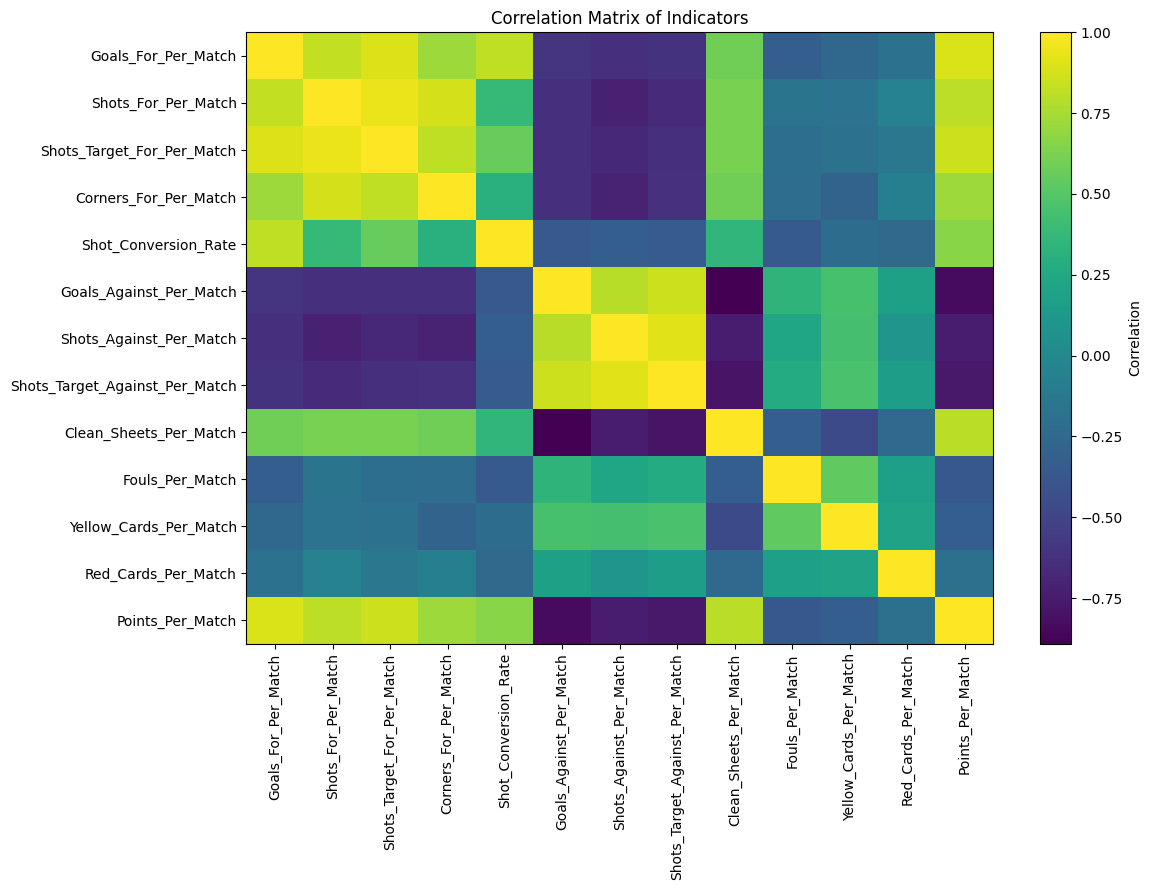

In [11]:
analysis_cols = [
    'Goals_For_Per_Match', 'Shots_For_Per_Match', 'Shots_Target_For_Per_Match',
    'Corners_For_Per_Match', 'Shot_Conversion_Rate',
    'Goals_Against_Per_Match', 'Shots_Against_Per_Match', 'Shots_Target_Against_Per_Match',
    'Clean_Sheets_Per_Match', 'Fouls_Per_Match', 'Yellow_Cards_Per_Match', 'Red_Cards_Per_Match',
    'Points_Per_Match'
]

corr = agg[analysis_cols].corr()

plt.figure(figsize=(12, 9))
plt.imshow(corr, aspect='auto')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar(label='Correlation')
plt.title('Correlation Matrix of Indicators')
plt.tight_layout()
plt.savefig(VISUALS_DIR / 'correlation_matrix.png', dpi=200)
plt.show()

## 9. Normalisation

The variables are on different scales, so they must be normalised before combining them. Min-Max normalisation is used so that each indicator is transformed to a 0 to 1 scale.

For negative indicators, such as goals against or fouls, the values are inverted so that **higher is always better**.

In [12]:
def minmax(series):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return pd.Series(0.5, index=series.index)
    return (series - min_val) / (max_val - min_val)

index_df = agg.copy()

# Positive indicators: higher is better
positive_indicators = [
    'Goals_For_Per_Match',
    'Shots_For_Per_Match',
    'Shots_Target_For_Per_Match',
    'Corners_For_Per_Match',
    'Shot_Conversion_Rate',
    'Clean_Sheets_Per_Match',
]

# Negative indicators: lower is better, so invert after scaling
negative_indicators = [
    'Goals_Against_Per_Match',
    'Shots_Against_Per_Match',
    'Shots_Target_Against_Per_Match',
    'Fouls_Per_Match',
    'Yellow_Cards_Per_Match',
    'Red_Cards_Per_Match',
]

for col in positive_indicators:
    index_df[col + '_Norm'] = index_df.groupby('Season')[col].transform(minmax)

for col in negative_indicators:
    index_df[col + '_Norm'] = 1 - index_df.groupby('Season')[col].transform(minmax)

index_df.head()

,Season,Team,Matches,Points,Wins,Draws,Losses,Goals_For,Goals_Against,Shots_For,Shots_Against,Shots_Target_For,Shots_Target_Against,Corners_For,Corners_Against,Fouls,Yellow_Cards,Red_Cards,Clean_Sheets,Goals_For_Per_Match,Goals_Against_Per_Match,Shots_For_Per_Match,Shots_Against_Per_Match,Shots_Target_For_Per_Match,Shots_Target_Against_Per_Match,Corners_For_Per_Match,Corners_Against_Per_Match,Fouls_Per_Match,Yellow_Cards_Per_Match,Red_Cards_Per_Match,Clean_Sheets_Per_Match,Goal_Difference,Goal_Difference_Per_Match,Shot_Conversion_Rate,Points_Per_Match,League_Rank,Goals_For_Per_Match_Norm,Shots_For_Per_Match_Norm,Shots_Target_For_Per_Match_Norm,Corners_For_Per_Match_Norm,Shot_Conversion_Rate_Norm,Clean_Sheets_Per_Match_Norm,Goals_Against_Per_Match_Norm,Shots_Against_Per_Match_Norm,Shots_Target_Against_Per_Match_Norm,Fouls_Per_Match_Norm,Yellow_Cards_Per_Match_Norm,Red_Cards_Per_Match_Norm
0,2020_21,Arsenal,38,61,18,7,13,55,39,459,416,152,132,208,166,345,47,5,12,1.447368,1.026316,12.078947,10.947368,4.000000,3.473684,5.473684,4.368421,9.078947,1.236842,0.131579,0.315789,16,0.421053,0.119826,1.605263,8,0.555556,0.473498,0.441667,0.547826,0.638009,0.500000,0.840909,0.582803,0.780822,1.000000,0.787879,0.166667
1,2020_21,Aston Villa,38,55,16,7,15,55,46,511,538,187,189,215,194,439,63,3,15,1.447368,1.210526,13.447368,14.157895,4.921053,4.973684,5.657895,5.105263,11.552632,1.657895,0.078947,0.394737,9,0.236842,0.107632,1.447368,11,0.555556,0.657244,0.733333,0.608696,0.505567,0.714286,0.681818,0.194268,0.390411,0.323741,0.303030,0.500000
2,2020_21,Brighton,38,41,9,14,15,40,46,487,358,143,127,219,167,427,45,6,12,1.052632,1.210526,12.815789,9.421053,3.763158,3.342105,5.763158,4.394737,11.236842,1.184211,0.157895,0.315789,-6,-0.157895,0.082136,1.078947,16,0.317460,0.572438,0.366667,0.643478,0.228633,0.500000,0.681818,0.767516,0.815068,0.410072,0.848485,0.000000
3,2020_21,Burnley,38,39,10,9,19,33,55,384,573,130,187,172,239,384,48,0,11,0.868421,1.447368,10.105263,15.078947,3.421053,4.921053,4.526316,6.289474,10.105263,1.263158,0.000000,0.289474,-22,-0.578947,0.085938,1.026316,17,0.206349,0.208481,0.258333,0.234783,0.269928,0.428571,0.477273,0.082803,0.404110,0.719424,0.757576,1.000000
4,2020_21,Chelsea,38,67,19,10,9,58,36,558,336,209,109,227,160,433,48,3,18,1.526316,0.947368,14.684211,8.842105,5.500000,2.868421,5.973684,4.210526,11.394737,1.263158,0.078947,0.473684,22,0.578947,0.103943,1.763158,4,0.603175,0.823322,0.916667,0.713043,0.465494,0.928571,0.909091,0.837580,0.938356,0.366906,0.757576,0.500000


## 10. Weighting and Aggregation

Three sub-indices are created:

### Attack Index
- Goals for per match
- Shots for per match
- Shots on target for per match
- Corners for per match
- Shot conversion rate

### Defence Index
- Goals against per match, inverted
- Shots against per match, inverted
- Shots on target against per match, inverted
- Clean sheet rate

### Discipline Index
- Fouls per match, inverted
- Yellow cards per match, inverted
- Red cards per match, inverted

The final composite index is calculated as:

**Final Index = 40% Attack + 40% Defence + 20% Discipline**

In [13]:
index_df['Attack_Index'] = index_df[
    [
        'Goals_For_Per_Match_Norm',
        'Shots_For_Per_Match_Norm',
        'Shots_Target_For_Per_Match_Norm',
        'Corners_For_Per_Match_Norm',
        'Shot_Conversion_Rate_Norm'
    ]
].mean(axis=1)

index_df['Defence_Index'] = index_df[
    [
        'Goals_Against_Per_Match_Norm',
        'Shots_Against_Per_Match_Norm',
        'Shots_Target_Against_Per_Match_Norm',
        'Clean_Sheets_Per_Match_Norm'
    ]
].mean(axis=1)

index_df['Discipline_Index'] = index_df[
    [
        'Fouls_Per_Match_Norm',
        'Yellow_Cards_Per_Match_Norm',
        'Red_Cards_Per_Match_Norm'
    ]
].mean(axis=1)

index_df['Composite_Index'] = (
    0.4 * index_df['Attack_Index'] +
    0.4 * index_df['Defence_Index'] +
    0.2 * index_df['Discipline_Index']
)

index_df['Composite_Rank'] = (
    index_df.sort_values(['Season', 'Composite_Index'], ascending=[True, False])
            .groupby('Season')
            .cumcount() + 1
)

output_cols = [
    'Season', 'Team', 'Matches', 'Points', 'League_Rank',
    'Attack_Index', 'Defence_Index', 'Discipline_Index',
    'Composite_Index', 'Composite_Rank'
]

index_df[output_cols].sort_values(['Season', 'Composite_Rank']).head(20)

,Season,Team,Matches,Points,League_Rank,Attack_Index,Defence_Index,Discipline_Index,Composite_Index,Composite_Rank
11,2020_21,Man City,38,86,1,0.940381,1.000000,0.789914,0.934135,1
10,2020_21,Liverpool,38,69,3,0.854307,0.704623,0.877698,0.799111,2
4,2020_21,Chelsea,38,67,4,0.704340,0.903400,0.541494,0.751395,3
9,2020_21,Leicester,38,66,5,0.700586,0.621210,0.627716,0.654262,4
12,2020_21,Man United,38,74,2,0.757215,0.650290,0.445425,0.652087,5
0,2020_21,Arsenal,38,61,8,0.531311,0.676133,0.651515,0.613281,6
18,2020_21,West Ham,38,65,6,0.539482,0.540359,0.682981,0.568532,7
16,2020_21,Tottenham,38,62,7,0.604813,0.540197,0.532156,0.564435,8
8,2020_21,Leeds,38,59,9,0.714105,0.359698,0.535681,0.536657,9
2,2020_21,Brighton,38,41,16,0.425735,0.691101,0.419519,0.530638,10


## 11. Cluster Analysis

K-means clustering is used to group teams with similar profiles based on their attack, defence and discipline scores.

Three clusters are used as a simple and interpretable choice:

- Strong / balanced teams
- Mid-performing teams
- Weaker or unbalanced teams

In a full report, this could be improved by using the elbow method or silhouette score.

In [14]:
cluster_features = index_df[['Attack_Index', 'Defence_Index', 'Discipline_Index']].copy()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
index_df['Cluster'] = kmeans.fit_predict(cluster_features)

index_df[['Season', 'Team', 'Attack_Index', 'Defence_Index', 'Discipline_Index', 'Cluster']].head()

,Season,Team,Attack_Index,Defence_Index,Discipline_Index,Cluster
0,2020_21,Arsenal,0.531311,0.676133,0.651515,1
1,2020_21,Aston Villa,0.612079,0.495196,0.375590,1
2,2020_21,Brighton,0.425735,0.691101,0.419519,1
3,2020_21,Burnley,0.235575,0.348189,0.825667,1
4,2020_21,Chelsea,0.704340,0.903400,0.541494,2


## 12. Visualisation of Results

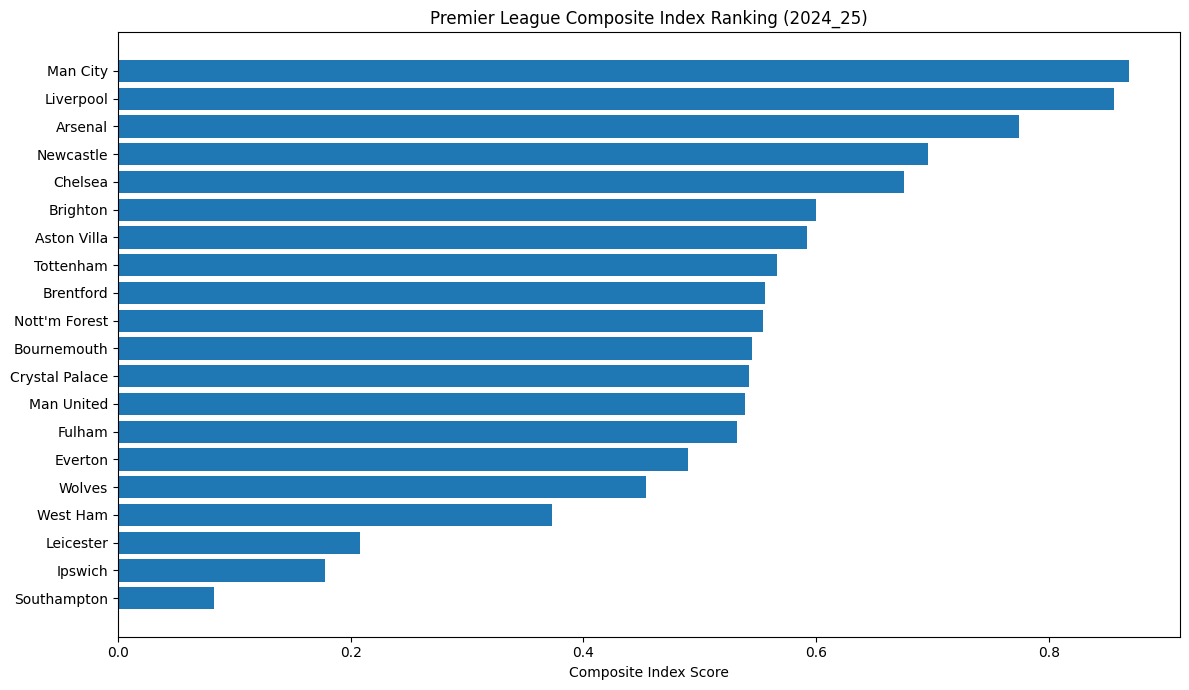

In [15]:
# Choose latest season available for clear visualisation
latest_season = sorted(index_df['Season'].unique())[-1]
latest = index_df[index_df['Season'] == latest_season].sort_values('Composite_Index', ascending=False)

plt.figure(figsize=(12, 7))
plt.barh(latest['Team'], latest['Composite_Index'])
plt.gca().invert_yaxis()
plt.xlabel('Composite Index Score')
plt.title(f'Premier League Composite Index Ranking ({latest_season})')
plt.tight_layout()
plt.savefig(VISUALS_DIR / 'final_index_ranking.png', dpi=200)
plt.show()

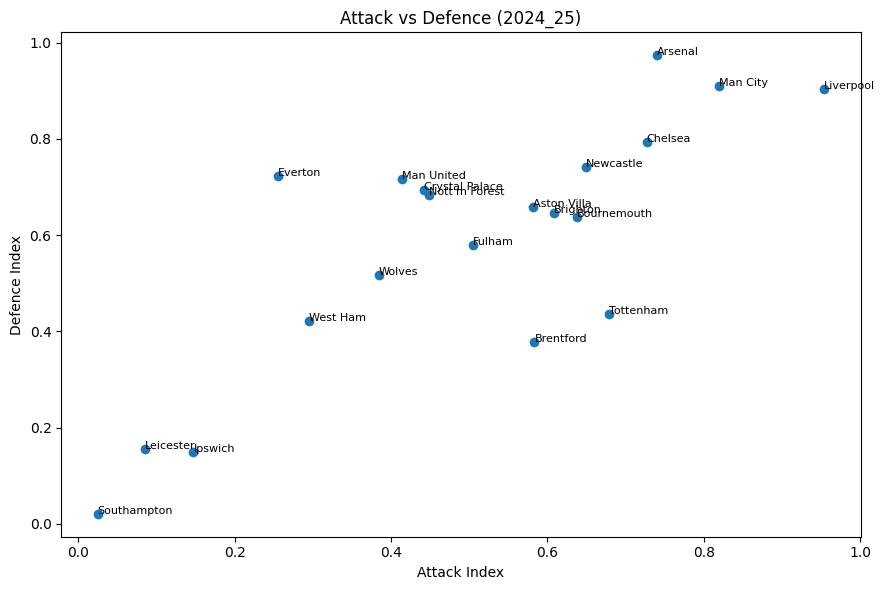

In [16]:
plt.figure(figsize=(9, 6))
plt.scatter(latest['Attack_Index'], latest['Defence_Index'])
for _, row in latest.iterrows():
    plt.text(row['Attack_Index'], row['Defence_Index'], row['Team'], fontsize=8)
plt.xlabel('Attack Index')
plt.ylabel('Defence Index')
plt.title(f'Attack vs Defence ({latest_season})')
plt.tight_layout()
plt.savefig(VISUALS_DIR / 'attack_vs_defence.png', dpi=200)
plt.show()

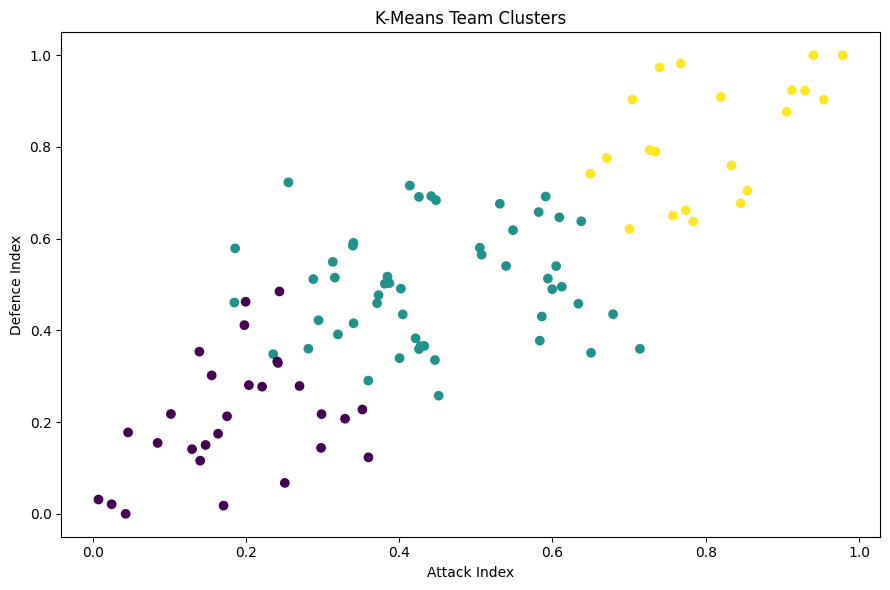

In [17]:
plt.figure(figsize=(9, 6))
plt.scatter(index_df['Attack_Index'], index_df['Defence_Index'], c=index_df['Cluster'])
plt.xlabel('Attack Index')
plt.ylabel('Defence Index')
plt.title('K-Means Team Clusters')
plt.tight_layout()
plt.savefig(VISUALS_DIR / 'team_clusters.png', dpi=200)
plt.show()

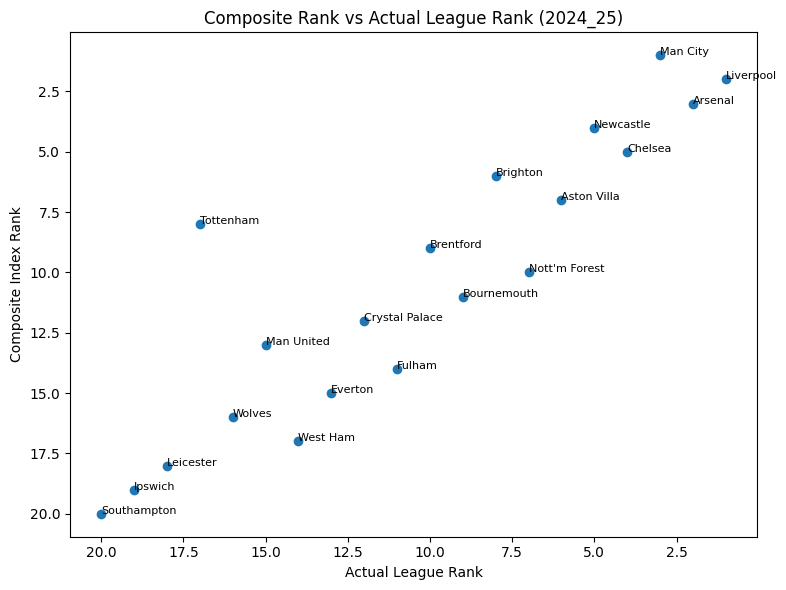

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(latest['League_Rank'], latest['Composite_Rank'])
for _, row in latest.iterrows():
    plt.text(row['League_Rank'], row['Composite_Rank'], row['Team'], fontsize=8)
plt.xlabel('Actual League Rank')
plt.ylabel('Composite Index Rank')
plt.title(f'Composite Rank vs Actual League Rank ({latest_season})')
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(VISUALS_DIR / 'rank_comparison.png', dpi=200)
plt.show()

### 10.6 Composite Index Rank vs League Table Rank

This visualisation compares the ranking produced by the composite index with the actual Premier League table ranking based on points. This helps evaluate whether the index reflects real-world league performance.

If teams appear close to the diagonal pattern, it suggests the composite index is broadly consistent with the actual league table. Teams that are far away from the expected pattern may have unusual statistical profiles, such as strong underlying performance but fewer points, or good results despite weaker performance indicators.

In [19]:
# Visual 6: Composite Index Rank vs League Table Rank

import pandas as pd
import matplotlib.pyplot as plt

# Load the processed team-season index dataset
team_season_df = pd.read_csv(PROCESSED_DIR / "team_season_index.csv")

print("Columns available:")
print(team_season_df.columns.tolist())

team_season_df.head()

Columns available:
['Season', 'Team', 'Matches', 'Points', 'Wins', 'Draws', 'Losses', 'Goals_For', 'Goals_Against', 'Shots_For', 'Shots_Against', 'Shots_Target_For', 'Shots_Target_Against', 'Corners_For', 'Corners_Against', 'Fouls', 'Yellow_Cards', 'Red_Cards', 'Clean_Sheets', 'Goals_For_Per_Match', 'Goals_Against_Per_Match', 'Shots_For_Per_Match', 'Shots_Against_Per_Match', 'Shots_Target_For_Per_Match', 'Shots_Target_Against_Per_Match', 'Corners_For_Per_Match', 'Corners_Against_Per_Match', 'Fouls_Per_Match', 'Yellow_Cards_Per_Match', 'Red_Cards_Per_Match', 'Clean_Sheets_Per_Match', 'Goal_Difference', 'Goal_Difference_Per_Match', 'Shot_Conversion_Rate', 'Points_Per_Match', 'League_Rank', 'Goals_For_Per_Match_Norm', 'Shots_For_Per_Match_Norm', 'Shots_Target_For_Per_Match_Norm', 'Corners_For_Per_Match_Norm', 'Shot_Conversion_Rate_Norm', 'Clean_Sheets_Per_Match_Norm', 'Goals_Against_Per_Match_Norm', 'Shots_Against_Per_Match_Norm', 'Shots_Target_Against_Per_Match_Norm', 'Fouls_Per_Match_No

,Season,Team,Matches,Points,Wins,Draws,Losses,Goals_For,Goals_Against,Shots_For,Shots_Against,Shots_Target_For,Shots_Target_Against,Corners_For,Corners_Against,Fouls,Yellow_Cards,Red_Cards,Clean_Sheets,Goals_For_Per_Match,Goals_Against_Per_Match,Shots_For_Per_Match,Shots_Against_Per_Match,Shots_Target_For_Per_Match,Shots_Target_Against_Per_Match,Corners_For_Per_Match,Corners_Against_Per_Match,Fouls_Per_Match,Yellow_Cards_Per_Match,Red_Cards_Per_Match,Clean_Sheets_Per_Match,Goal_Difference,Goal_Difference_Per_Match,Shot_Conversion_Rate,Points_Per_Match,League_Rank,Goals_For_Per_Match_Norm,Shots_For_Per_Match_Norm,Shots_Target_For_Per_Match_Norm,Corners_For_Per_Match_Norm,Shot_Conversion_Rate_Norm,Clean_Sheets_Per_Match_Norm,Goals_Against_Per_Match_Norm,Shots_Against_Per_Match_Norm,Shots_Target_Against_Per_Match_Norm,Fouls_Per_Match_Norm,Yellow_Cards_Per_Match_Norm,Red_Cards_Per_Match_Norm,Attack_Index,Defence_Index,Discipline_Index,Composite_Index,Composite_Rank,Cluster
0,2020_21,Arsenal,38,61,18,7,13,55,39,459,416,152,132,208,166,345,47,5,12,1.447368,1.026316,12.078947,10.947368,4.000000,3.473684,5.473684,4.368421,9.078947,1.236842,0.131579,0.315789,16,0.421053,0.119826,1.605263,8,0.555556,0.473498,0.441667,0.547826,0.638009,0.500000,0.840909,0.582803,0.780822,1.000000,0.787879,0.166667,0.531311,0.676133,0.651515,0.613281,6,1
1,2020_21,Aston Villa,38,55,16,7,15,55,46,511,538,187,189,215,194,439,63,3,15,1.447368,1.210526,13.447368,14.157895,4.921053,4.973684,5.657895,5.105263,11.552632,1.657895,0.078947,0.394737,9,0.236842,0.107632,1.447368,11,0.555556,0.657244,0.733333,0.608696,0.505567,0.714286,0.681818,0.194268,0.390411,0.323741,0.303030,0.500000,0.612079,0.495196,0.375590,0.518028,11,1
2,2020_21,Brighton,38,41,9,14,15,40,46,487,358,143,127,219,167,427,45,6,12,1.052632,1.210526,12.815789,9.421053,3.763158,3.342105,5.763158,4.394737,11.236842,1.184211,0.157895,0.315789,-6,-0.157895,0.082136,1.078947,16,0.317460,0.572438,0.366667,0.643478,0.228633,0.500000,0.681818,0.767516,0.815068,0.410072,0.848485,0.000000,0.425735,0.691101,0.419519,0.530638,10,1
3,2020_21,Burnley,38,39,10,9,19,33,55,384,573,130,187,172,239,384,48,0,11,0.868421,1.447368,10.105263,15.078947,3.421053,4.921053,4.526316,6.289474,10.105263,1.263158,0.000000,0.289474,-22,-0.578947,0.085938,1.026316,17,0.206349,0.208481,0.258333,0.234783,0.269928,0.428571,0.477273,0.082803,0.404110,0.719424,0.757576,1.000000,0.235575,0.348189,0.825667,0.398639,15,1
4,2020_21,Chelsea,38,67,19,10,9,58,36,558,336,209,109,227,160,433,48,3,18,1.526316,0.947368,14.684211,8.842105,5.500000,2.868421,5.973684,4.210526,11.394737,1.263158,0.078947,0.473684,22,0.578947,0.103943,1.763158,4,0.603175,0.823322,0.916667,0.713043,0.465494,0.928571,0.909091,0.837580,0.938356,0.366906,0.757576,0.500000,0.704340,0.903400,0.541494,0.751395,3,2


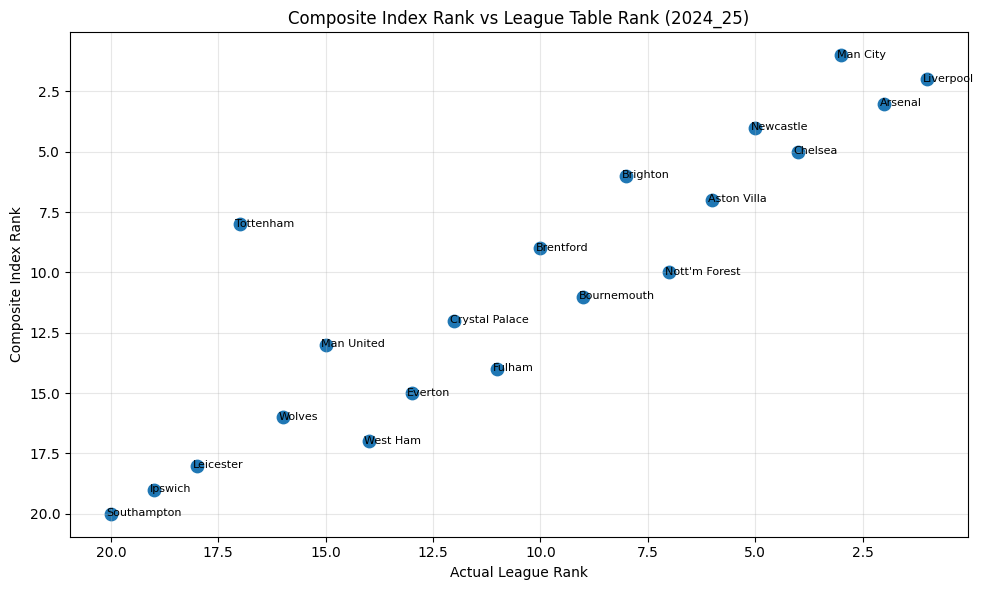

Saved visualisation to: c:\Users\ehima\Downloads\dav_premier_league_notebook_project\dav_premier_league_notebook_project\visuals\composite_rank_vs_league_rank.png


In [20]:
# Create Composite Rank vs League Rank visualisation

latest_season = team_season_df["Season"].max()
latest_df = team_season_df[team_season_df["Season"] == latest_season].copy()

# Create ranks if they do not already exist
if "Composite_Rank" not in latest_df.columns:
    latest_df["Composite_Rank"] = latest_df["Composite_Index"].rank(ascending=False, method="min")

if "League_Rank" not in latest_df.columns:
    latest_df["League_Rank"] = latest_df["Points"].rank(ascending=False, method="min")

plt.figure(figsize=(10, 6))

plt.scatter(
    latest_df["League_Rank"],
    latest_df["Composite_Rank"],
    s=80
)

for _, row in latest_df.iterrows():
    plt.text(
        row["League_Rank"] + 0.1,
        row["Composite_Rank"] + 0.1,
        row["Team"],
        fontsize=8
    )

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.xlabel("Actual League Rank")
plt.ylabel("Composite Index Rank")
plt.title(f"Composite Index Rank vs League Table Rank ({latest_season})")
plt.grid(True, alpha=0.3)

output_path = VISUALS_DIR / "composite_rank_vs_league_rank.png"
plt.tight_layout()
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved visualisation to: {output_path}")

### 10.7 Sub-Index Comparison for Selected Teams

This visualisation compares the sub-index scores for selected teams. It shows how the final composite index is built from different dimensions of performance.

This is useful because two teams may have similar final scores but different performance profiles. For example, one team may be stronger in attack while another may be stronger defensively. Showing the sub-indices makes the composite indicator easier to interpret.

In [21]:
# Visual 7: Sub-Index Comparison for Selected Teams

import pandas as pd
import matplotlib.pyplot as plt

# Load the processed team-season index dataset
team_season_df = pd.read_csv(PROCESSED_DIR / "team_season_index.csv")

print("Columns available:")
print(team_season_df.columns.tolist())

latest_season = team_season_df["Season"].max()
latest_df = team_season_df[team_season_df["Season"] == latest_season].copy()

print("Teams available in latest season:")
print(sorted(latest_df["Team"].unique()))

Columns available:
['Season', 'Team', 'Matches', 'Points', 'Wins', 'Draws', 'Losses', 'Goals_For', 'Goals_Against', 'Shots_For', 'Shots_Against', 'Shots_Target_For', 'Shots_Target_Against', 'Corners_For', 'Corners_Against', 'Fouls', 'Yellow_Cards', 'Red_Cards', 'Clean_Sheets', 'Goals_For_Per_Match', 'Goals_Against_Per_Match', 'Shots_For_Per_Match', 'Shots_Against_Per_Match', 'Shots_Target_For_Per_Match', 'Shots_Target_Against_Per_Match', 'Corners_For_Per_Match', 'Corners_Against_Per_Match', 'Fouls_Per_Match', 'Yellow_Cards_Per_Match', 'Red_Cards_Per_Match', 'Clean_Sheets_Per_Match', 'Goal_Difference', 'Goal_Difference_Per_Match', 'Shot_Conversion_Rate', 'Points_Per_Match', 'League_Rank', 'Goals_For_Per_Match_Norm', 'Shots_For_Per_Match_Norm', 'Shots_Target_For_Per_Match_Norm', 'Corners_For_Per_Match_Norm', 'Shot_Conversion_Rate_Norm', 'Clean_Sheets_Per_Match_Norm', 'Goals_Against_Per_Match_Norm', 'Shots_Against_Per_Match_Norm', 'Shots_Target_Against_Per_Match_Norm', 'Fouls_Per_Match_No

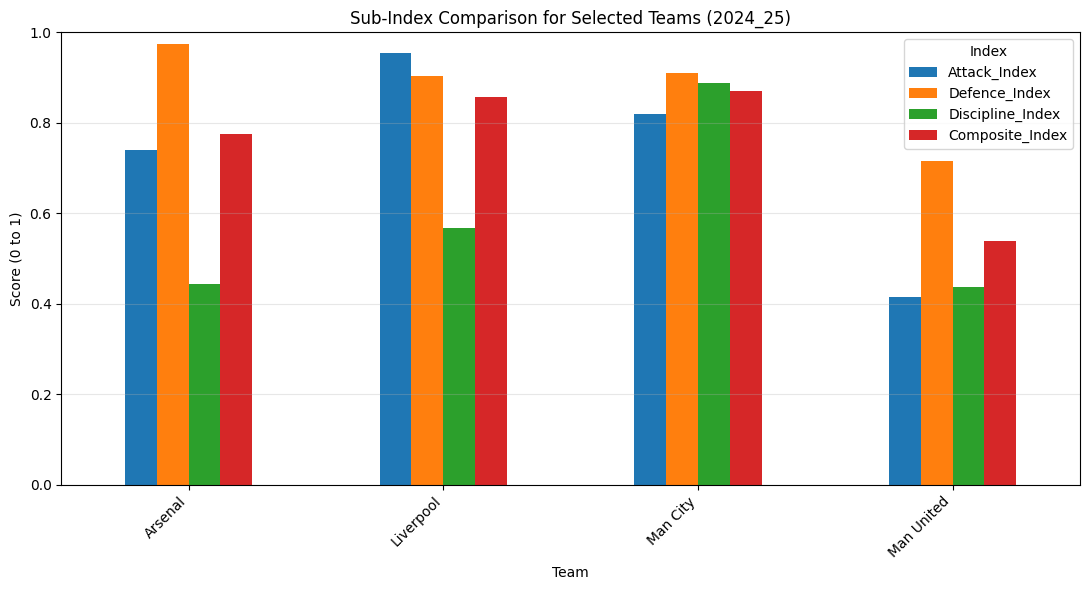

Saved visualisation to: c:\Users\ehima\Downloads\dav_premier_league_notebook_project\dav_premier_league_notebook_project\visuals\sub_index_comparison_selected_teams.png


In [22]:
# Create Sub-Index Comparison for Selected Teams

selected_teams = ["Man United", "Arsenal", "Liverpool", "Man City"]

comparison_df = latest_df[latest_df["Team"].isin(selected_teams)].copy()

# If the exact names do not match, fall back to the top 4 teams by composite index
if comparison_df.empty or comparison_df["Team"].nunique() < 2:
    comparison_df = latest_df.sort_values("Composite_Index", ascending=False).head(4).copy()

comparison_columns = [
    "Attack_Index",
    "Defence_Index",
    "Discipline_Index",
    "Composite_Index"
]

comparison_plot_df = comparison_df.set_index("Team")[comparison_columns]

comparison_plot_df.plot(kind="bar", figsize=(11, 6))

plt.title(f"Sub-Index Comparison for Selected Teams ({latest_season})")
plt.xlabel("Team")
plt.ylabel("Score (0 to 1)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend(title="Index")
plt.grid(axis="y", alpha=0.3)

output_path = VISUALS_DIR / "sub_index_comparison_selected_teams.png"
plt.tight_layout()
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved visualisation to: {output_path}")

## 13. Export Final Dataset

In [23]:
final_path = PROCESSED_DIR / 'team_season_index.csv'
index_df.to_csv(final_path, index=False)
print(f'Saved final dataset to: {final_path}')

Saved final dataset to: c:\Users\ehima\Downloads\dav_premier_league_notebook_project\dav_premier_league_notebook_project\data\processed\team_season_index.csv


## Final Output Check

This final check confirms that the processed dataset and visualisations were created successfully. This supports reproducibility because the examiner can verify the expected output files after running the notebook.

In [24]:
# Final output check

expected_files = [
    PROCESSED_DIR / "team_season_index.csv",
    VISUALS_DIR / "composite_rank_vs_league_rank.png",
    VISUALS_DIR / "sub_index_comparison_selected_teams.png"
]

for file in expected_files:
    if file.exists():
        print(f"Created successfully: {file}")
    else:
        print(f"Missing file: {file}")

print("\nFinal processed dataset preview:")
final_df = pd.read_csv(PROCESSED_DIR / "team_season_index.csv")
display(final_df.head())
print(f"Final dataset shape: {final_df.shape}")

Created successfully: c:\Users\ehima\Downloads\dav_premier_league_notebook_project\dav_premier_league_notebook_project\data\processed\team_season_index.csv
Created successfully: c:\Users\ehima\Downloads\dav_premier_league_notebook_project\dav_premier_league_notebook_project\visuals\composite_rank_vs_league_rank.png
Created successfully: c:\Users\ehima\Downloads\dav_premier_league_notebook_project\dav_premier_league_notebook_project\visuals\sub_index_comparison_selected_teams.png

Final processed dataset preview:


,Season,Team,Matches,Points,Wins,Draws,Losses,Goals_For,Goals_Against,Shots_For,Shots_Against,Shots_Target_For,Shots_Target_Against,Corners_For,Corners_Against,Fouls,Yellow_Cards,Red_Cards,Clean_Sheets,Goals_For_Per_Match,Goals_Against_Per_Match,Shots_For_Per_Match,Shots_Against_Per_Match,Shots_Target_For_Per_Match,Shots_Target_Against_Per_Match,Corners_For_Per_Match,Corners_Against_Per_Match,Fouls_Per_Match,Yellow_Cards_Per_Match,Red_Cards_Per_Match,Clean_Sheets_Per_Match,Goal_Difference,Goal_Difference_Per_Match,Shot_Conversion_Rate,Points_Per_Match,League_Rank,Goals_For_Per_Match_Norm,Shots_For_Per_Match_Norm,Shots_Target_For_Per_Match_Norm,Corners_For_Per_Match_Norm,Shot_Conversion_Rate_Norm,Clean_Sheets_Per_Match_Norm,Goals_Against_Per_Match_Norm,Shots_Against_Per_Match_Norm,Shots_Target_Against_Per_Match_Norm,Fouls_Per_Match_Norm,Yellow_Cards_Per_Match_Norm,Red_Cards_Per_Match_Norm,Attack_Index,Defence_Index,Discipline_Index,Composite_Index,Composite_Rank,Cluster
0,2020_21,Arsenal,38,61,18,7,13,55,39,459,416,152,132,208,166,345,47,5,12,1.447368,1.026316,12.078947,10.947368,4.000000,3.473684,5.473684,4.368421,9.078947,1.236842,0.131579,0.315789,16,0.421053,0.119826,1.605263,8,0.555556,0.473498,0.441667,0.547826,0.638009,0.500000,0.840909,0.582803,0.780822,1.000000,0.787879,0.166667,0.531311,0.676133,0.651515,0.613281,6,1
1,2020_21,Aston Villa,38,55,16,7,15,55,46,511,538,187,189,215,194,439,63,3,15,1.447368,1.210526,13.447368,14.157895,4.921053,4.973684,5.657895,5.105263,11.552632,1.657895,0.078947,0.394737,9,0.236842,0.107632,1.447368,11,0.555556,0.657244,0.733333,0.608696,0.505567,0.714286,0.681818,0.194268,0.390411,0.323741,0.303030,0.500000,0.612079,0.495196,0.375590,0.518028,11,1
2,2020_21,Brighton,38,41,9,14,15,40,46,487,358,143,127,219,167,427,45,6,12,1.052632,1.210526,12.815789,9.421053,3.763158,3.342105,5.763158,4.394737,11.236842,1.184211,0.157895,0.315789,-6,-0.157895,0.082136,1.078947,16,0.317460,0.572438,0.366667,0.643478,0.228633,0.500000,0.681818,0.767516,0.815068,0.410072,0.848485,0.000000,0.425735,0.691101,0.419519,0.530638,10,1
3,2020_21,Burnley,38,39,10,9,19,33,55,384,573,130,187,172,239,384,48,0,11,0.868421,1.447368,10.105263,15.078947,3.421053,4.921053,4.526316,6.289474,10.105263,1.263158,0.000000,0.289474,-22,-0.578947,0.085938,1.026316,17,0.206349,0.208481,0.258333,0.234783,0.269928,0.428571,0.477273,0.082803,0.404110,0.719424,0.757576,1.000000,0.235575,0.348189,0.825667,0.398639,15,1
4,2020_21,Chelsea,38,67,19,10,9,58,36,558,336,209,109,227,160,433,48,3,18,1.526316,0.947368,14.684211,8.842105,5.500000,2.868421,5.973684,4.210526,11.394737,1.263158,0.078947,0.473684,22,0.578947,0.103943,1.763158,4,0.603175,0.823322,0.916667,0.713043,0.465494,0.928571,0.909091,0.837580,0.938356,0.366906,0.757576,0.500000,0.704340,0.903400,0.541494,0.751395,3,2


Final dataset shape: (100, 54)


## Export Summary Results

The final step exports the top and bottom ranked team-seasons from the composite index. This makes the final results easier to inspect and reference in the report.

In [25]:
# Export top and bottom ranked team-seasons

final_df = pd.read_csv(PROCESSED_DIR / "team_season_index.csv")

top_10 = final_df.sort_values("Composite_Index", ascending=False).head(10)
bottom_10 = final_df.sort_values("Composite_Index", ascending=True).head(10)

top_10.to_csv(PROCESSED_DIR / "top_10_team_seasons.csv", index=False)
bottom_10.to_csv(PROCESSED_DIR / "bottom_10_team_seasons.csv", index=False)

print("Top 10 team-seasons exported:")
display(top_10[["Season", "Team", "Composite_Index"]].head(10))

print("Bottom 10 team-seasons exported:")
display(bottom_10[["Season", "Team", "Composite_Index"]].head(10))

Top 10 team-seasons exported:


,Season,Team,Composite_Index
31,2021_22,Man City,0.991525
11,2020_21,Man City,0.934135
52,2022_23,Man City,0.927699
30,2021_22,Liverpool,0.906154
72,2023_24,Man City,0.893907
92,2024_25,Man City,0.869286
91,2024_25,Liverpool,0.856246
60,2023_24,Arsenal,0.835184
40,2022_23,Arsenal,0.809432
10,2020_21,Liverpool,0.799111


Bottom 10 team-seasons exported:


,Season,Team,Composite_Index
76,2023_24,Sheffield United,0.075360
96,2024_25,Southampton,0.082355
14,2020_21,Sheffield United,0.134790
28,2021_22,Leeds,0.167230
34,2021_22,Norwich,0.171119
89,2024_25,Ipswich,0.177523
17,2020_21,West Brom,0.180503
59,2022_23,Wolves,0.198742
65,2023_24,Burnley,0.200862
55,2022_23,Nott'm Forest,0.204915


## Project Workflow

This notebook follows the composite indicator development process:

1. Load multiple Premier League CSV datasets.
2. Inspect and clean the data.
3. Transform match-level data into team-season data.
4. Check missing values.
5. Carry out multivariate analysis.
6. Normalise indicators.
7. Create attack, defence and discipline sub-indices.
8. Aggregate sub-indices into a final composite index.
9. Apply clustering to group similar teams.
10. Visualise and interpret the results.

## 14. Interpretation Notes for Report

Use the generated outputs Focus on:

- Which teams rank highest and why
- Whether the index agrees with the actual league table
- Which teams are strong in attack but weak in defence
- Whether discipline changes the final ranking
- What the cluster analysis shows
- Limitations of the index

Possible limitations:

- The index does not include player injuries, squad value, fixture difficulty, possession or expected goals.
- The weighting scheme is partly theoretical and could be adjusted.
- Match statistics may not capture tactical quality or context.